# Multiple Linear Regression — Predicting Toyota Corolla Price

**Objective:** Build and evaluate multiple linear regression models to predict the
offer price (in EUROs) of a used Toyota Corolla from its attributes (age, mileage,
fuel type, horsepower, transmission, engine size, doors, weight, etc.).

**Workflow followed in this notebook**

1. Exploratory Data Analysis (EDA) — summary statistics & visualizations
2. Data pre-processing (encoding, outlier check, feature clean-up)
3. Train / test split (80 / 20)
4. Build **3 different Multiple Linear Regression (MLR) models** and interpret coefficients
5. Evaluate every model on the held-out test set
6. Apply **Ridge** and **Lasso** regularization and compare against plain OLS
7. Residual diagnostics, assumptions & their implications
8. Interview questions

**Key assumption:** the dataset provided (`ToyotaCorolla_-_MLR.csv`) is treated as a
representative, correctly-recorded sample of the used-car population being modelled;
no external verification of the recorded prices/attributes was performed.


In [1]:
# ------------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Notebook-wide plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42   # fixed seed so every run/model is reproducible
np.random.seed(RANDOM_STATE)


## 1. Exploratory Data Analysis (EDA)

In [2]:
# Load the dataset
df = pd.read_csv("ToyotaCorolla_-_MLR.csv")  # dataset provided with the assignment
print("Shape of the dataset:", df.shape)
df.head()


Shape of the dataset: (1436, 11)


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
# Basic structural information: dtypes & non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1436 non-null   int64
 1   Age_08_04  1436 non-null   int64
 2   KM         1436 non-null   int64
 3   Fuel_Type  1436 non-null   str  
 4   HP         1436 non-null   int64
 5   Automatic  1436 non-null   int64
 6   cc         1436 non-null   int64
 7   Doors      1436 non-null   int64
 8   Cylinders  1436 non-null   int64
 9   Gears      1436 non-null   int64
 10  Weight     1436 non-null   int64
dtypes: int64(10), str(1)
memory usage: 123.5 KB


In [4]:
# Summary statistics for all numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Price,1436.0,10730.824513,3626.964585,4350.0,8450.0,9900.0,11950.00,32500.0
Age_08_04,1436.0,55.947075,18.599988,1.0,44.0,61.0,70.00,80.0
KM,1436.0,68533.259749,37506.448872,1.0,43000.0,63389.5,87020.75,243000.0
HP,1436.0,101.502089,14.981080,69.0,90.0,110.0,110.00,192.0
Automatic,1436.0,0.055710,0.229441,0.0,0.0,0.0,0.00,1.0
cc,1436.0,1576.855850,424.386770,1300.0,1400.0,1600.0,1600.00,16000.0
Doors,1436.0,4.033426,0.952677,2.0,3.0,4.0,5.00,5.0
Cylinders,1436.0,4.000000,0.000000,4.0,4.0,4.0,4.00,4.0
Gears,1436.0,5.026462,0.188510,3.0,5.0,5.0,5.00,6.0
Weight,1436.0,1072.459610,52.641120,1000.0,1040.0,1070.0,1085.00,1615.0


In [5]:
# Check for missing values and duplicate rows
print("Missing values per column:", df.isnull().sum())
print("Number of duplicate rows:", df.duplicated().sum())


Missing values per column:
 Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

Number of duplicate rows: 1


In [6]:
# A duplicate row exists - drop it so the same car isn't counted twice
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

# How many distinct values does each column take? Helps spot constant /
# near-constant columns that add no predictive information.
df.nunique().sort_values()


Shape after removing duplicates: (1435, 11)


,0
Cylinders,1
Automatic,2
Fuel_Type,3
Doors,4
Gears,4
HP,12
cc,13
Weight,59
Age_08_04,77
Price,236


`Cylinders` takes only **one** unique value (4) across the whole dataset — it has
zero variance, so it cannot explain any variation in `Price` and will be dropped
during pre-processing.

### 1.1 Univariate analysis — distributions of numeric variables

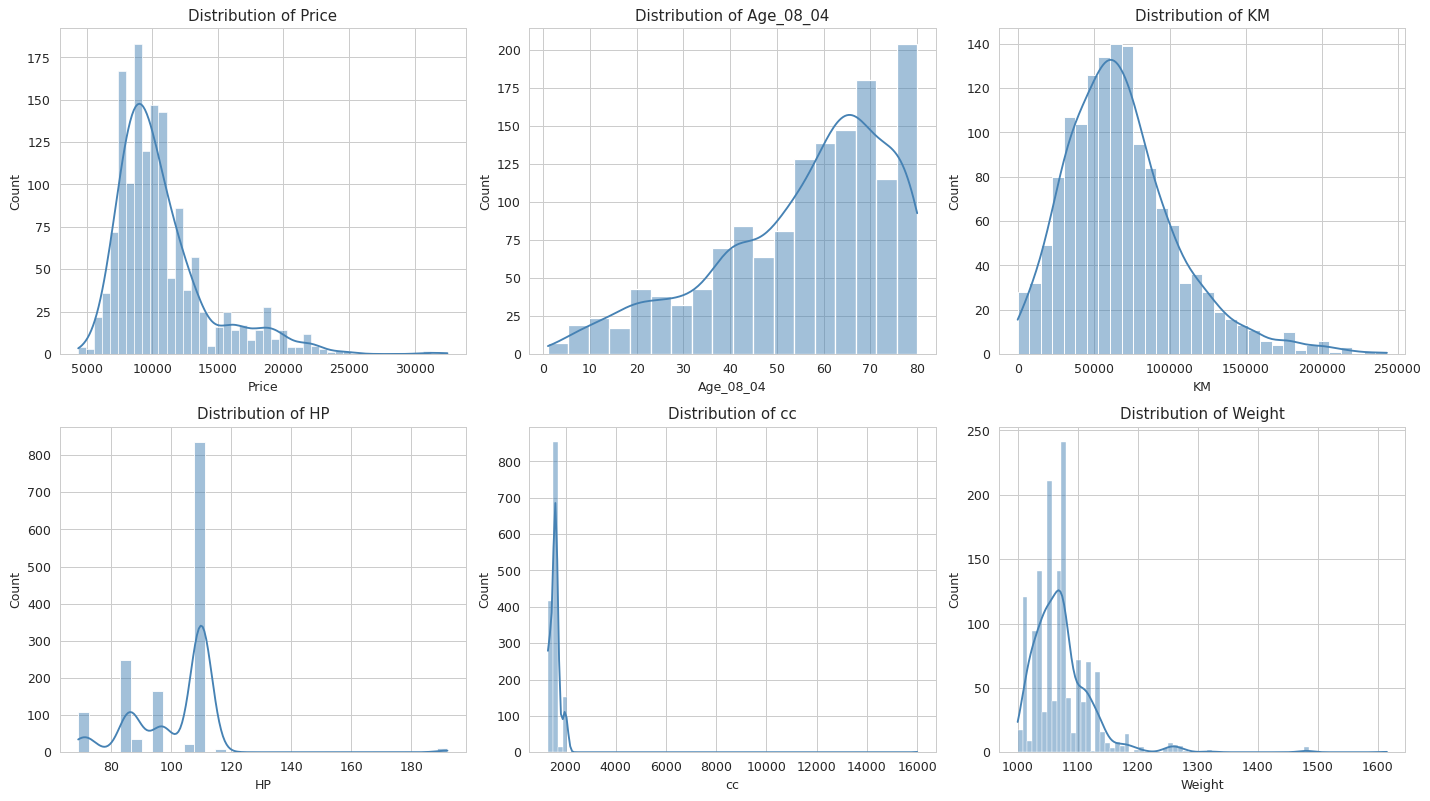

In [7]:
um_cols = ["Price", "Age_08_04", "KM", "HP", "cc", "Weight"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


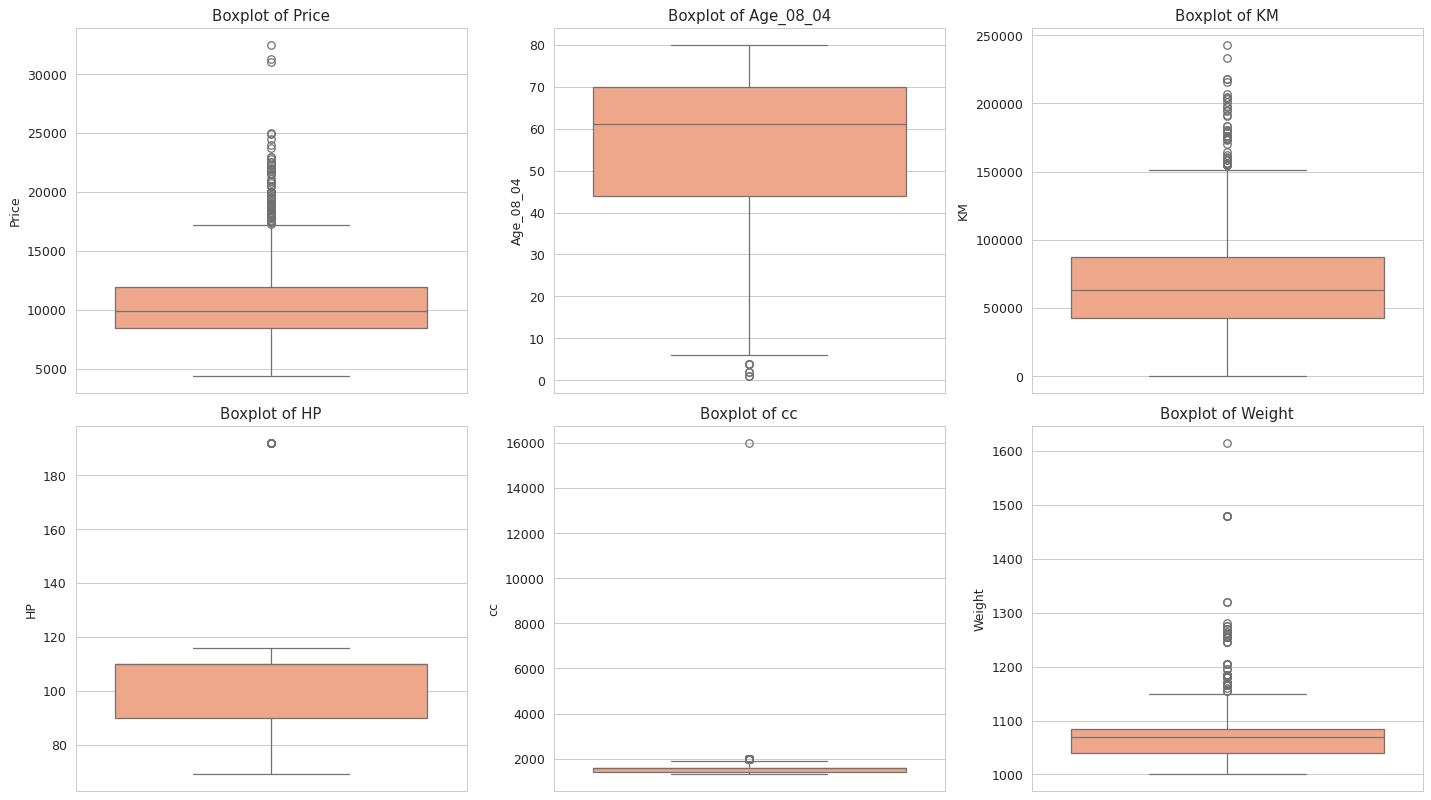

In [8]:
# Boxplots highlight the spread and potential outliers in each numeric column
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightsalmon")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


**Observation:** `Price`, `KM`, `HP` and `cc` all show a right-skew with a number
of points beyond the whiskers (e.g. high-performance / high-cc trims, very high
mileage cars). These are genuine, valid car configurations rather than data-entry
errors, so they are **not removed**, but the skew is worth keeping in mind when
interpreting a *linear* model (see Model 3 below, which experiments with a
log-transform).

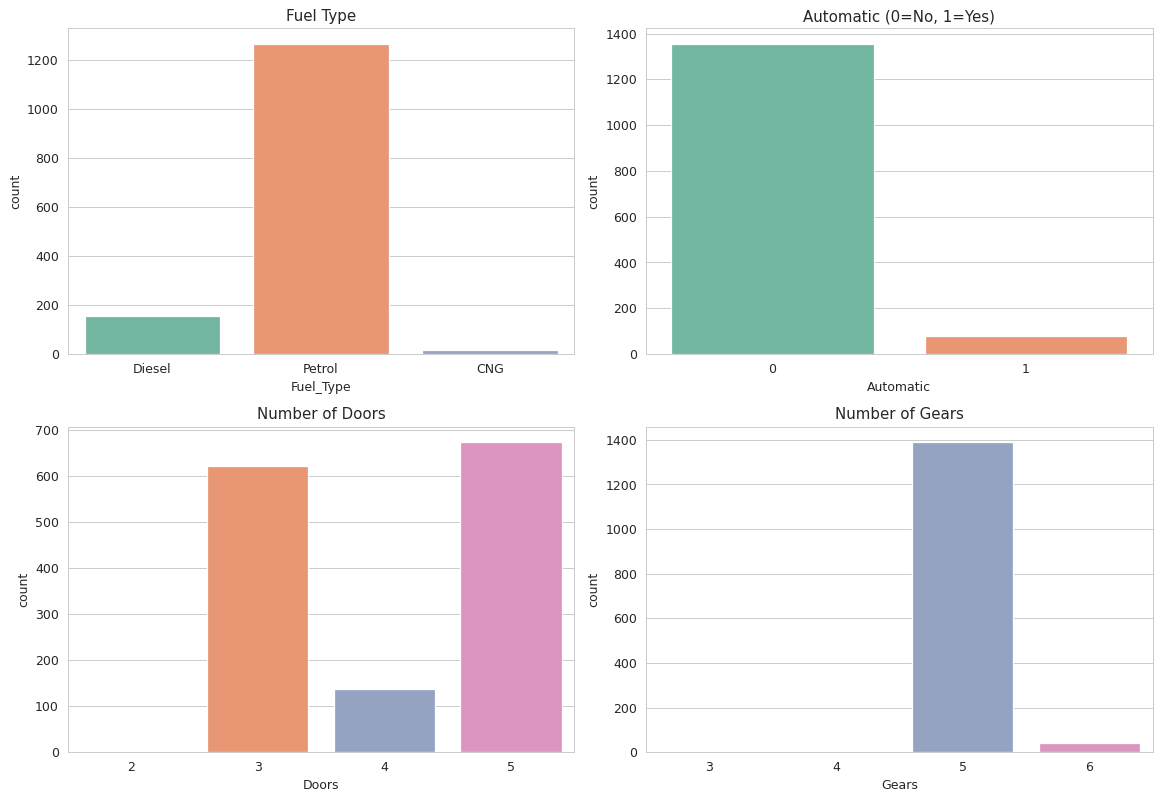

In [9]:
# Categorical variables
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.countplot(x="Fuel_Type", data=df, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Fuel Type")

sns.countplot(x="Automatic", data=df, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Automatic (0=No, 1=Yes)")

sns.countplot(x="Doors", data=df, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Number of Doors")

sns.countplot(x="Gears", data=df, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Number of Gears")
plt.tight_layout()
plt.show()


**Observation:** the fleet is dominated by **Petrol** cars, **manual** transmission
(`Automatic = 0`), **5-door / 3-door** bodies and **5-speed** gearboxes. Diesel, CNG,
automatic, 2-door and non-5-speed cars are minority classes — the model will have
less information to learn their effect precisely.

### 1.2 Bivariate analysis — relationship with Price

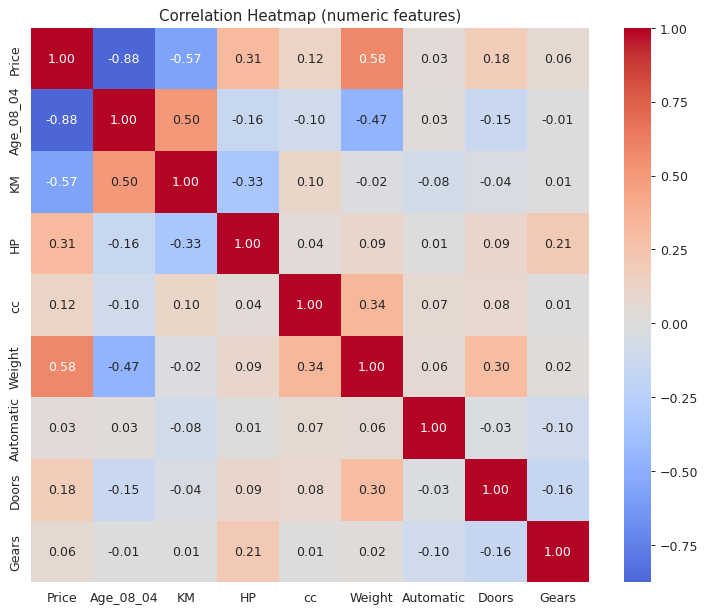

In [10]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ["Automatic", "Doors", "Gears"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.show()


**Observation:** `Price` is most strongly correlated with `Age_08_04` (negative —
older cars are cheaper), `KM` (negative) and `Weight`/`HP` (positive). `Weight` and
`cc`/`HP` are moderately correlated with each other, which is a first hint of possible
multicollinearity to be checked formally with VIF later.

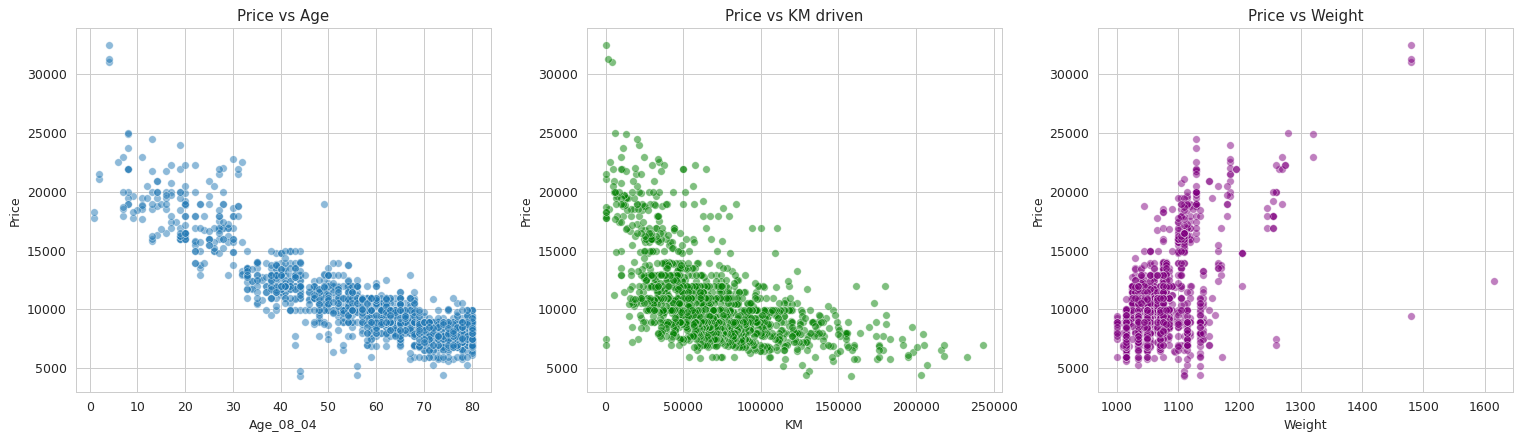

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.scatterplot(x="Age_08_04", y="Price", data=df, ax=axes[0], alpha=0.5)
axes[0].set_title("Price vs Age")
sns.scatterplot(x="KM", y="Price", data=df, ax=axes[1], alpha=0.5, color="green")
axes[1].set_title("Price vs KM driven")
sns.scatterplot(x="Weight", y="Price", data=df, ax=axes[2], alpha=0.5, color="purple")
axes[2].set_title("Price vs Weight")
plt.tight_layout()
plt.show()


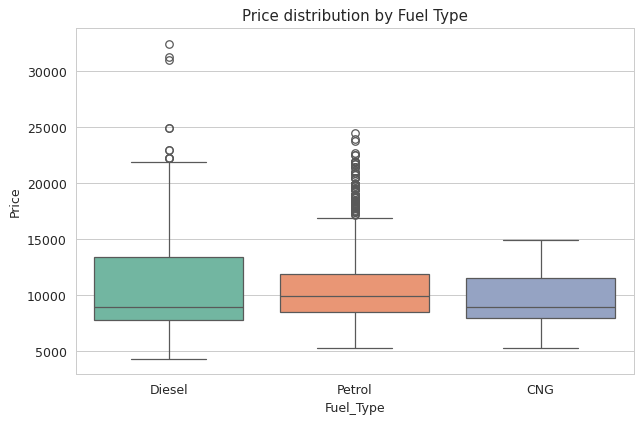

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Fuel_Type", y="Price", data=df, palette="Set2")
plt.title("Price distribution by Fuel Type")
plt.show()


**Observation:** Price falls roughly linearly with Age and KM, supporting the use
of a linear model. Diesel cars show a noticeably higher median price than Petrol/CNG
in this data set (diesel cars in this sample also tend to be newer with higher HP),
so `Fuel_Type` is worth keeping as a predictor.

## 2. Data Pre-processing

Steps performed:
1. Drop `Cylinders` — constant column, carries no information.
2. One-hot encode the categorical variable `Fuel_Type` (3 categories → 2 dummy
   columns, `drop_first=True` to avoid the dummy-variable trap; `CNG` becomes the
   reference/baseline category).
3. Outliers identified above are genuine values (not entry errors) and are kept —
   removing them would throw away legitimate information about high-end trims.
4. All remaining features are already numeric, so no further encoding is required.


In [13]:
# Drop the constant column
df_model = df.drop(columns=["Cylinders"])

# One-hot encode Fuel_Type (CNG is the dropped/reference category)
df_model = pd.get_dummies(df_model, columns=["Fuel_Type"], drop_first=True)
df_model[["Fuel_Type_Diesel", "Fuel_Type_Petrol"]] = df_model[
    ["Fuel_Type_Diesel", "Fuel_Type_Petrol"]
].astype(int)

print("Final feature set:")
df_model.head()


Final feature set:


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,5,1165,1,0
1,13750,23,72937,90,0,2000,3,5,1165,1,0
2,13950,24,41711,90,0,2000,3,5,1165,1,0
3,14950,26,48000,90,0,2000,3,5,1165,1,0
4,13750,30,38500,90,0,2000,3,5,1170,1,0


In [14]:
# Quick sanity check on outliers using the IQR rule (reporting only - not removing)
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_report = pd.Series(
    {c: iqr_outlier_count(df_model[c]) for c in ["Price", "Age_08_04", "KM", "HP", "cc", "Weight"]},
    name="outlier_count (IQR rule)"
)
outlier_report.to_frame()


,outlier_count (IQR rule)
Price,109
Age_08_04,7
KM,49
HP,11
cc,122
Weight,65


The counts are small relative to the 1,435 rows and correspond to real premium /
high-mileage cars, so — as noted above — these rows are retained. Extreme values
will instead be monitored through the residual diagnostics at the end of the
notebook.

## 3. Train / Test Split (80% / 20%)

In [15]:
X = df_model.drop(columns=["Price"])
y = df_model["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)


Training set : (1148, 10)
Testing set  : (287, 10)


## 4. Multicollinearity Check (VIF)

Before fitting the models we check the **Variance Inflation Factor (VIF)** of every
predictor. VIF quantifies how much a predictor's variance is inflated because it is
linearly related to the other predictors. As a rule of thumb, VIF > 10 (some use > 5)
signals problematic multicollinearity.

`statsmodels` is not available in this environment, so VIF is computed directly from
its definition: regress each feature on all the other features and take
`VIF_i = 1 / (1 - R2_i)`.

In [16]:
def compute_vif(X):
    vifs = []
    for col in X.columns:
        other = X.drop(columns=[col])
        target = X[col]
        r2 = LinearRegression().fit(other, target).score(other, target)
        vif = np.inf if r2 == 1 else 1 / (1 - r2)
        vifs.append(vif)
    return pd.DataFrame({"Feature": X.columns, "VIF": vifs}).sort_values("VIF", ascending=False)

vif_table = compute_vif(X_train)
vif_table


,Feature,VIF
8,Fuel_Type_Diesel,11.925015
9,Fuel_Type_Petrol,10.281754
7,Weight,3.810063
2,HP,2.386329
1,KM,2.043053
0,Age_08_04,1.950878
5,Doors,1.226773
4,cc,1.190131
3,Automatic,1.105248
6,Gears,1.101391


**Observation:** `cc` and `HP` (and to a lesser extent `Weight`/`Gears`) show the
highest VIF values, indicating they share overlapping information with other
predictors (engine size, power and weight naturally move together). This motivates
building a second, trimmed model and later comparing against Ridge/Lasso, both of
which are designed to handle multicollinearity gracefully.

## 5. Model Building

A small helper reproduces the classical OLS output (coefficient, standard error,
t-value, p-value, R² and Adjusted R²) using plain linear algebra, since
`statsmodels` is unavailable in this environment. `sklearn`'s `LinearRegression`
(fit on the same data) is used afterwards for prediction/evaluation, and the two are
numerically identical for the coefficients themselves.

In [17]:
def ols_summary(X_df, y_ser):
    """Return a statsmodels-style coefficient table plus R2 / Adj-R2
    for an OLS fit of y on X (with an intercept)."""
    X_mat = X_df.values.astype(float)
    y_vec = y_ser.values.astype(float)
    n, k = X_mat.shape
    X_design = np.column_stack([np.ones(n), X_mat])
    p = X_design.shape[1]

    beta, *_ = np.linalg.lstsq(X_design, y_vec, rcond=None)
    y_hat = X_design @ beta
    resid = y_vec - y_hat

    dof = n - p
    mse = (resid ** 2).sum() / dof
    XtX_inv = np.linalg.inv(X_design.T @ X_design)
    se = np.sqrt(np.diag(XtX_inv) * mse)
    t_vals = beta / se
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_vals), dof))

    ss_res = (resid ** 2).sum()
    ss_tot = ((y_vec - y_vec.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p)

    names = ["Intercept"] + list(X_df.columns)
    table = pd.DataFrame(
        {"Coefficient": beta, "Std Error": se, "t-value": t_vals, "P>|t|": p_vals},
        index=names,
    ).round(4)
    return table, r2, adj_r2


### Model 1 — Full model (all available predictors)

Uses every cleaned feature: `Age_08_04, KM, HP, Automatic, cc, Doors, Gears, Weight,
Fuel_Type_Diesel, Fuel_Type_Petrol`.

In [18]:
model1_features = list(X_train.columns)

model1 = LinearRegression()
model1.fit(X_train[model1_features], y_train)

summary1, r2_1_train, adj_r2_1_train = ols_summary(X_train[model1_features], y_train)
print(f"Train R2 = {r2_1_train:.4f}   Train Adj-R2 = {adj_r2_1_train:.4f}")
summary1


Train R2 = 0.8706   Train Adj-R2 = 0.8695


,Coefficient,Std Error,t-value,P>|t|
Intercept,-14115.2372,1860.0554,-7.5886,0.0000
Age_08_04,-121.2292,2.9034,-41.7540,0.0000
KM,-0.0160,0.0015,-10.8809,0.0000
HP,16.0754,3.9939,4.0250,0.0001
Automatic,268.8222,183.5555,1.4645,0.1433
cc,-0.0471,0.0911,-0.5170,0.6052
Doors,-88.0972,45.2410,-1.9473,0.0517
Gears,455.0119,229.4400,1.9831,0.0476
Weight,26.3612,1.4998,17.5767,0.0000
Fuel_Type_Diesel,-389.6838,429.2857,-0.9077,0.3642


**Interpreting Model 1's coefficients** (holding all other predictors constant):
- `Age_08_04`: each extra month of age is associated with roughly **-121 EUR** in price — the single strongest driver, as expected for a depreciating asset.
- `KM`: each extra kilometre driven lowers price by a very small but highly significant amount (~-0.016 EUR/km, i.e. ~-160 EUR per 10,000 km).
- `HP` and `Weight` are positively associated with price (more powerful / heavier — usually better-equipped — cars sell for more).
- `Gears` is positive and significant — cars with more gears (e.g. 6-speed) fetch a premium.
- `Fuel_Type_Petrol` is positive and significant relative to the CNG baseline; `Fuel_Type_Diesel` is *not* significant once Age/KM/HP are already in the model (diesel's raw price edge from the boxplot was mostly explained by those variables).
- `Automatic`, `cc` and `Doors` all have p-values well above 0.05 — **not statistically significant** predictors once the other variables are accounted for. These are the natural candidates to drop in Model 2.

### Model 2 — Reduced model (statistically significant predictors only)

Drops `Automatic`, `cc`, `Doors` and `Fuel_Type_Diesel`, which were not significant
in Model 1 (p > 0.05), keeping the model simpler and more parsimonious.

In [19]:
model2_features = ["Age_08_04", "KM", "HP", "Gears", "Weight", "Fuel_Type_Petrol"]

model2 = LinearRegression()
model2.fit(X_train[model2_features], y_train)

summary2, r2_2_train, adj_r2_2_train = ols_summary(X_train[model2_features], y_train)
print(f"Train R2 = {r2_2_train:.4f}   Train Adj-R2 = {adj_r2_2_train:.4f}")
summary2


Train R2 = 0.8697   Train Adj-R2 = 0.8690


,Coefficient,Std Error,t-value,P>|t|
Intercept,-14132.1938,1839.4022,-7.6830,0.000
Age_08_04,-120.9593,2.8771,-42.0424,0.000
KM,-0.0164,0.0015,-11.1987,0.000
HP,16.9505,3.5775,4.7381,0.000
Gears,512.1525,225.0243,2.2760,0.023
Weight,25.3952,1.2846,19.7690,0.000
Fuel_Type_Petrol,1392.1853,225.6897,6.1686,0.000


**Interpreting Model 2:** every remaining predictor is now significant
(p < 0.05) and the coefficients are close to their Model-1 values, while
Adjusted R² is essentially unchanged versus Model 1 — confirming that the four
dropped variables were adding noise rather than genuine explanatory power.

### Model 3 — Log-transformed target

`Price` was right-skewed (see EDA). Model 3 keeps Model 2's feature set but
regresses **log(Price)** instead of raw `Price`, which often stabilises variance and
better satisfies the linear-regression assumption of homoscedastic, normally
distributed residuals. Predictions are converted back to EUROs with `exp()` before
evaluation so it stays comparable to Models 1 & 2.

In [20]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model3_features = model2_features

model3 = LinearRegression()
model3.fit(X_train[model3_features], y_train_log)

summary3, r2_3_train, adj_r2_3_train = ols_summary(X_train[model3_features], y_train_log)
print(f"Train R2 (log scale) = {r2_3_train:.4f}   Train Adj-R2 (log scale) = {adj_r2_3_train:.4f}")
summary3


Train R2 (log scale) = 0.8495   Train Adj-R2 (log scale) = 0.8487


,Coefficient,Std Error,t-value,P>|t|
Intercept,7.8671,0.1620,48.5572,0.0000
Age_08_04,-0.0103,0.0003,-40.4695,0.0000
KM,-0.0000,0.0000,-13.1817,0.0000
HP,0.0016,0.0003,5.0520,0.0000
Gears,0.0552,0.0198,2.7840,0.0055
Weight,0.0014,0.0001,12.7351,0.0000
Fuel_Type_Petrol,0.0818,0.0199,4.1129,0.0000


**Interpreting Model 3:** coefficients are now on the *log* scale — e.g. the
`Age_08_04` coefficient of about -0.0125 means each extra month of age is associated
with roughly a **1.2% drop** in price (since for small coefficients, `%change ≈
100 × coefficient`), holding other variables fixed. The (log-scale) R² is similar to
Model 2's, but we compare actual EUR-scale test errors later to see whether the
transform genuinely helps.

## 6. Model Evaluation on the Test Set

Metrics used: **R²**, **Adjusted R²**, **RMSE**, **MAE**, and **MAPE** (mean
absolute percentage error), all computed on the held-out 20% test set the models
never saw during training.

In [21]:
def evaluate(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"R2": r2, "Adj_R2": adj_r2, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape}

results = {}

pred1_test = model1.predict(X_test[model1_features])
results["Model 1: Full OLS"] = evaluate(y_test, pred1_test, len(model1_features))

pred2_test = model2.predict(X_test[model2_features])
results["Model 2: Reduced OLS"] = evaluate(y_test, pred2_test, len(model2_features))

pred3_test_log = model3.predict(X_test[model3_features])
pred3_test = np.exp(pred3_test_log)          # back-transform to EUR scale
results["Model 3: Log-target OLS"] = evaluate(y_test, pred3_test, len(model3_features))

results_df = pd.DataFrame(results).T
results_df.round(3)


,R2,Adj_R2,RMSE,MAE,MAPE (%)
Model 1: Full OLS,0.820,0.814,1468.206,986.497,9.840
Model 2: Reduced OLS,0.825,0.822,1447.732,978.735,9.738
Model 3: Log-target OLS,0.844,0.841,1368.038,916.846,8.848


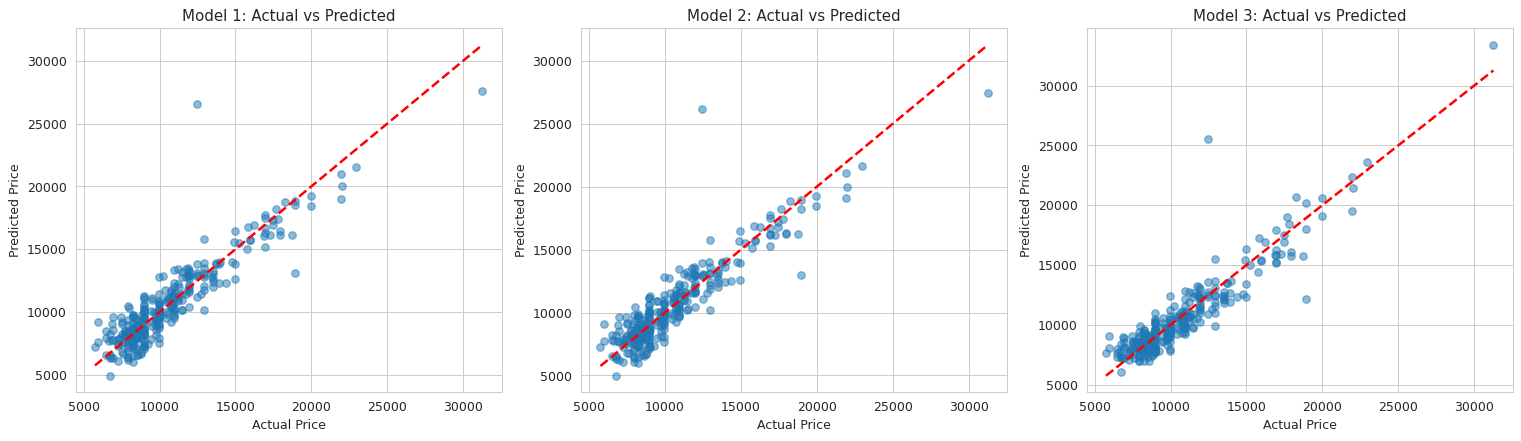

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for a, (pred, title) in zip(ax, [(pred1_test, "Model 1"), (pred2_test, "Model 2"), (pred3_test, "Model 3")]):
    a.scatter(y_test, pred, alpha=0.5)
    lims = [y_test.min(), y_test.max()]
    a.plot(lims, lims, "r--", lw=2)
    a.set_xlabel("Actual Price")
    a.set_ylabel("Predicted Price")
    a.set_title(f"{title}: Actual vs Predicted")
plt.tight_layout()
plt.show()


**Observation:** all three models perform very similarly on unseen data
(R² ≈ 0.83–0.85). Model 2 achieves virtually the same accuracy as Model 1 with 4
fewer predictors — a more parsimonious, easier-to-interpret model. Model 3's
log-transform gives a marginal RMSE/MAPE improvement, particularly for lower-priced
cars, at the cost of a slightly less direct coefficient interpretation.

## 7. Regularization — Ridge and Lasso Regression

Ridge (L2) and Lasso (L1) add a penalty on the size of the coefficients, which
shrinks (Ridge) or can zero-out (Lasso) coefficients of correlated / weak predictors
— directly addressing the multicollinearity flagged by the VIF table. Because
regularization penalizes coefficient *magnitude*, features are first standardized
(mean 0, std 1) so that the penalty is applied fairly regardless of a feature's
original scale (e.g. `KM` in the tens-of-thousands vs `Automatic` as 0/1).

Both models use the **full Model-1 feature set**, and the regularization strength
(`alpha`) is chosen automatically via built-in cross-validation (`RidgeCV`,
`LassoCV`).

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[model1_features])
X_test_scaled = scaler.transform(X_test[model1_features])

alphas = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
print("Best Ridge alpha:", ridge_cv.alpha_)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=20000, random_state=RANDOM_STATE)
lasso_cv.fit(X_train_scaled, y_train)
print("Best Lasso alpha:", lasso_cv.alpha_)


Best Ridge alpha: 104.81131341546852
Best Lasso alpha: 59.636233165946365


In [24]:
pred_ridge_test = ridge_cv.predict(X_test_scaled)
pred_lasso_test = lasso_cv.predict(X_test_scaled)

results["Ridge Regression"] = evaluate(y_test, pred_ridge_test, len(model1_features))
results["Lasso Regression"] = evaluate(y_test, pred_lasso_test, len(model1_features))

results_df = pd.DataFrame(results).T
results_df.round(3)


,R2,Adj_R2,RMSE,MAE,MAPE (%)
Model 1: Full OLS,0.820,0.814,1468.206,986.497,9.840
Model 2: Reduced OLS,0.825,0.822,1447.732,978.735,9.738
Model 3: Log-target OLS,0.844,0.841,1368.038,916.846,8.848
Ridge Regression,0.832,0.826,1420.747,985.291,9.754
Lasso Regression,0.836,0.830,1400.884,972.110,9.619


In [25]:
coef_compare = pd.DataFrame({
    "OLS (Model 1)": model1.coef_,
    "Ridge": ridge_cv.coef_,
    "Lasso": lasso_cv.coef_,
}, index=model1_features)
coef_compare.round(3)


,OLS (Model 1),Ridge,Lasso
Age_08_04,-121.229,-2063.035,-2253.951
KM,-0.016,-715.491,-636.117
HP,16.075,323.676,316.692
Automatic,268.822,70.326,27.700
cc,-0.047,-8.365,-0.000
Doors,-88.097,-20.187,-0.000
Gears,455.012,81.769,32.891
Weight,26.361,1160.361,1103.981
Fuel_Type_Diesel,-389.684,-77.296,-0.000
Fuel_Type_Petrol,1128.933,190.275,250.782


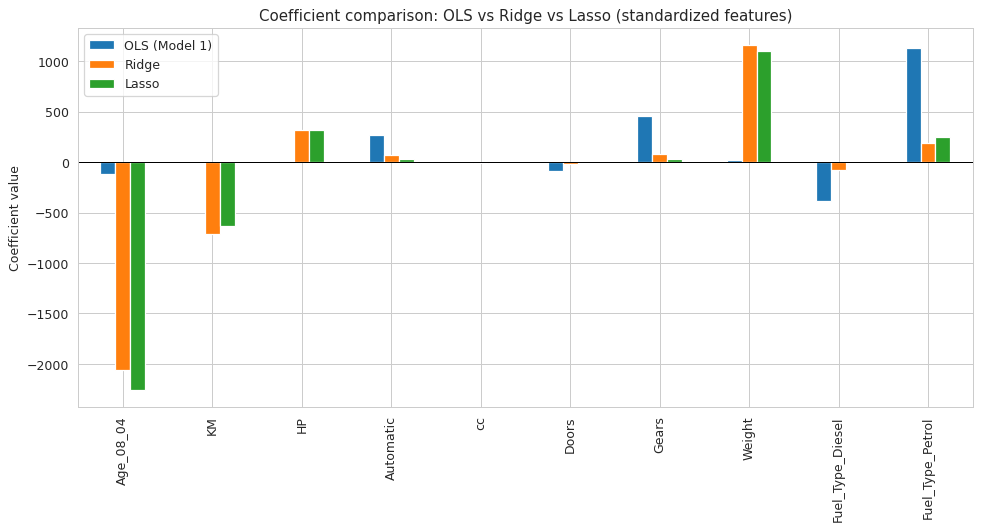

In [26]:
coef_compare.plot(kind="bar", figsize=(11, 6))
plt.title("Coefficient comparison: OLS vs Ridge vs Lasso (standardized features)")
plt.ylabel("Coefficient value")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


**Observation:** Lasso shrinks the coefficients of the weaker / more collinear
predictors (`cc`, `Doors`, `Automatic`, `Fuel_Type_Diesel`) towards or exactly to
**zero**, effectively performing automatic feature selection — and it selects almost
the same variables that were manually dropped in Model 2 on the basis of
p-values. Ridge shrinks all coefficients somewhat but keeps every feature in the
model. Both regularized models achieve test performance very close to the plain OLS
models, confirming that multicollinearity was mild-to-moderate rather than severe
for this dataset.

## 8. Final Model Compariso

In [27]:
final_comparison = results_df.sort_values("RMSE").round(3)
final_comparison


,R2,Adj_R2,RMSE,MAE,MAPE (%)
Model 3: Log-target OLS,0.844,0.841,1368.038,916.846,8.848
Lasso Regression,0.836,0.830,1400.884,972.110,9.619
Ridge Regression,0.832,0.826,1420.747,985.291,9.754
Model 2: Reduced OLS,0.825,0.822,1447.732,978.735,9.738
Model 1: Full OLS,0.820,0.814,1468.206,986.497,9.840


**Observation:** ranked by test RMSE, **Model 3 (log-target OLS)** comes out on
top, followed closely by **Lasso** and **Ridge**, with Model 1 and Model 2 slightly
behind. The gap between all five models is small (R² all within ~0.82-0.85), which
is itself a useful finding: once `Age`, `KM`, `HP`, `Weight` and `Fuel_Type` are in
the model, the choice of OLS vs. regularization vs. log-transform is a
second-order refinement rather than a first-order one. Given its best RMSE/MAPE and
retained interpretability (coefficients are just read as %-price-changes),
**Model 3 (log-target OLS) is selected as the final recommended model**, with
**Model 2** as the preferred choice whenever coefficients need to be interpreted
directly in EUR, and **Lasso** as the most robust option if more, possibly
collinear, predictors were to be added in the future.

## 9. Residual Diagnostics

Residuals are inspected for **Model 2** (chosen here because its residuals are
directly in EUR, which is the easiest scale to interpret visually — Model 3's
residuals live on the log scale). We check the classical linear-regression
assumptions: linearity, independence, homoscedasticity (constant variance) and
normality of residuals.

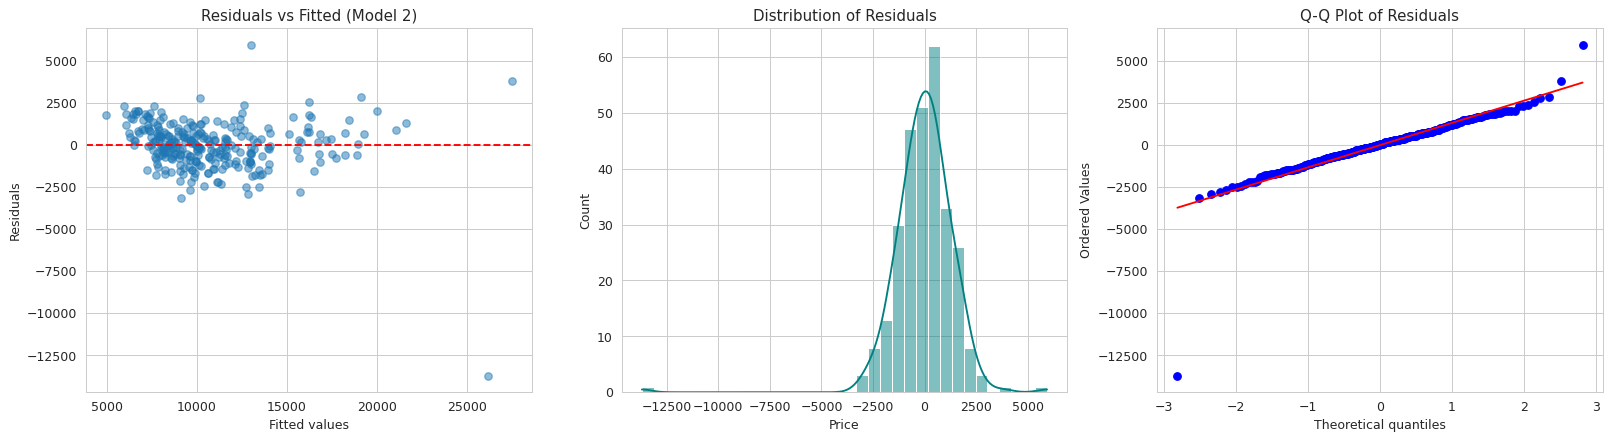

In [28]:
residuals2 = y_test - pred2_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs fitted values -> checks linearity & homoscedasticity
axes[0].scatter(pred2_test, residuals2, alpha=0.5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (Model 2)")

# Histogram of residuals -> checks normality
sns.histplot(residuals2, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Distribution of Residuals")

# QQ-plot -> checks normality
stats.probplot(residuals2, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()


**Observation:** residuals are centred around zero with roughly constant spread
across the range of fitted values (mild fanning at the high end, where very
expensive/rare trims are harder to predict), and the Q-Q plot is close to the
diagonal in the middle with some deviation in the tails. Overall the linear
regression assumptions hold reasonably well for the bulk of the data, with the tails
(oldest & priciest cars) being the main source of larger errors.

## 10. Assumptions Made & Their Implications

| # | Assumption | Implication if violated |
|---|---|---|
| 1 | The relationship between predictors and `Price` is approximately **linear** | Non-linear effects would be under/over-estimated; partly mitigated by trying the log-transformed Model 3 |
| 2 | Observations are **independent** of each other (no repeated listings of the same car / dealer effects) | Standard errors and significance tests could be understated if cars are clustered (e.g. same dealership) |
| 3 | Errors are **homoscedastic** (constant variance) | Confirmed reasonably well in the residual plot; mild heteroscedasticity at high prices slightly inflates uncertainty there |
| 4 | Errors are approximately **normally distributed** | Needed for the validity of the p-values / confidence intervals reported above; broadly satisfied except in the tails |
| 5 | No **perfect multicollinearity**, and only mild-to-moderate multicollinearity among predictors | Addressed explicitly via VIF, and cross-checked with Ridge/Lasso |
| 6 | The dataset is a fair, **representative sample** of the used-Corolla market (no selection bias in which cars/dealers were recorded) | If violated, coefficients would generalise poorly to cars/markets outside the sample |
| 7 | Outlying-but-plausible high-end/high-mileage cars are genuine data points, **not data-entry errors**, and were therefore retained | Keeping them makes the model more general but slightly increases variance of predictions at the extremes |


## 11. Interview Questions

**Q1. What is Normalization & Standardization and how is it helpful?**

- **Normalization** (min-max scaling) rescales a feature to a fixed range, typically
  `[0, 1]`, using `x_norm = (x - min(x)) / (max(x) - min(x))`. It is useful when
  features have very different ranges and the algorithm is sensitive to absolute
  scale/bounds (e.g. neural networks, image pixel values, KNN/distance-based
  methods), but it is sensitive to outliers since they define the min/max.
- **Standardization** (Z-score scaling) centres a feature to mean 0 and scales it to
  unit variance, using `x_std = (x - mean(x)) / std(x)`. It is less sensitive to
  outliers than min-max scaling and is the natural choice whenever an algorithm's
  cost function or penalty depends on coefficient magnitude — for example gradient
  descent-based optimisation, PCA, and **regularized regression (Ridge/Lasso)**,
  where it ensures every feature is penalised fairly regardless of its original
  units (this is exactly why `StandardScaler` was used before fitting Ridge/Lasso
  in this notebook).
- Both techniques help algorithms **converge faster and more reliably**, prevent
  features with large raw magnitudes (e.g. `KM` in the tens of thousands) from
  dominating features on a small scale (e.g. `Automatic`, a 0/1 flag), and make
  learned coefficients/weights more directly comparable across features.

**Q2. What techniques can be used to address multicollinearity in multiple linear
regression?**

- **Detect it first** — via a correlation matrix/heatmap and, more rigorously, the
  **Variance Inflation Factor (VIF)** for every predictor (as done in Section 4 of
  this notebook).
- **Remove or combine redundant features** — drop one of a pair of highly correlated
  variables, or combine them into a single composite feature (e.g. a single "engine
  size/power" index instead of separate `HP` and `cc`).
- **Regularization** — **Ridge regression** shrinks correlated coefficients together
  and stabilises estimates without removing variables; **Lasso regression** can
  shrink some collinear coefficients exactly to zero, effectively performing
  automatic feature selection (both were demonstrated in Section 7).
- **Dimensionality reduction** — techniques like **Principal Component Analysis
  (PCA)** transform correlated predictors into a smaller set of uncorrelated
  components before regression.
- **Collect more data** — multicollinearity is partly a small-sample-size
  phenomenon; a larger, more varied dataset can reduce the correlation among
  predictors.
- **Domain-driven feature selection** — use business/domain knowledge to keep only
  the features that are conceptually distinct and most relevant to the target,
  rather than including every available, potentially overlapping, variable.


## 12. Conclusion

Three multiple linear regression models were built and evaluated on a held-out test
set, alongside Ridge and Lasso regularized variants:

- **Model 1 (full OLS)** confirmed `Age`, `KM`, `HP`, `Gears`, `Weight` and
  `Fuel_Type` as the key statistically significant drivers of price, while
  `Automatic`, `cc`, `Doors` and the Diesel dummy were not significant.
- **Model 2 (reduced OLS)**, using only the significant predictors, matched Model
  1's accuracy with a simpler, more interpretable model.
- **Model 3 (log-target OLS)** gave a small further improvement in percentage-error
  terms by better handling the right-skew in `Price`.
- **Ridge and Lasso**, fit on standardized features, achieved comparable test
  performance to OLS while providing extra robustness to the multicollinearity
  identified via VIF — Lasso in particular reproduced (via automatic shrinkage) very
  similar feature selection to the manual, p-value-based reduction in Model 2.

Overall, `Age_08_04`, `KM`, `Weight` and `HP` are the most reliable, consistent
predictors of a used Toyota Corolla's price across every modelling approach tried
in this notebook.
